<a href="https://colab.research.google.com/github/jiang-h-y/gait-condition-classification/blob/main/analysis_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo

In [110]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
multivariate_gait_data = fetch_ucirepo(id=760)

# store data as df
df = multivariate_gait_data.data.features

In [4]:
df

,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399
...,...,...,...,...,...,...,...
181795,10,3,10,2,3,96,29.778412
181796,10,3,10,2,3,97,29.247559
181797,10,3,10,2,3,98,28.796951
181798,10,3,10,2,3,99,28.432936


In [84]:
# add identifier columns
tsf_df = df.copy()
tsf_df["subject_rep_cond"] = (
    df["subject"].astype(str) + "_" +
    df["replication"].astype(str) + "_" +
    df["condition"].astype(str)
)
tsf_df["leg_joint"] = df["leg"].astype("str") + "_" + df["joint"].astype("str")
tsf_df["all_id"] = tsf_df["subject_rep_cond"] + "_" + tsf_df["leg_joint"]

### Interdependent leg and joint angles
*Each observation contains measurements for each leg and joint combination, which captures that these angles are interdependent. However, this leads to a small dataset with a high risk of overfitting.*

In [85]:
# split training/testing data by subjects
train_subjects = random.sample(range(1, 11), 8)
test_subjects = [i for i in range(1, 11) if i not in train_subjects]

train_tsf = tsf_df[tsf_df["subject"].isin(train_subjects)]
test_tsf = tsf_df[tsf_df["subject"].isin(test_subjects)]

# try extracting features, where leg_joint features are considered interdependent
# results in fewer rows of data
X_train_tsf1_long = train_tsf[["time", "angle", "subject_rep_cond", "leg_joint"]]
X_test_tsf1_long = test_tsf[["time", "angle", "subject_rep_cond", "leg_joint"]]

X_train_tsf1 = impute(extract_features(
    X_train_tsf1_long, column_id="subject_rep_cond", column_kind="leg_joint",
    column_sort="time", column_value="angle", default_fc_parameters=EfficientFCParameters()
    ))
X_test_tsf1 = impute(extract_features(
    X_test_tsf1_long, column_id="subject_rep_cond", column_kind="leg_joint",
    column_sort="time", column_value="angle", default_fc_parameters=EfficientFCParameters()
))

# identify labels
y_train_tsf1 = train_tsf.groupby("subject_rep_cond")["condition"].first().reindex(X_train_tsf1.index)
y_test_tsf1 = test_tsf.groupby("subject_rep_cond")["condition"].first().reindex(X_test_tsf1.index)

Feature Extraction: 100%|██████████| 1440/1440 [02:53<00:00,  8.29it/s]
/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['1_1__fft_coefficient__attr_"real"__coeff_51'
 '1_1__fft_coefficient__attr_"real"__coeff_52'
 '1_1__fft_coefficient__attr_"real"__coeff_53' ...
 '2_3__fft_coefficient__attr_"angle"__coeff_98'
 '2_3__fft_coefficient__attr_"angle"__coeff_99'
 '2_3__query_similarity_count__query_None__threshold_0.0'] did not have any finite values. Filling with zeros.
  warnings.warn(
Feature Extraction: 100%|██████████| 360/360 [00:42<00:00,  8.57it/s]
/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['1_1__fft_coefficient__attr_"real"__coeff_51'
 '1_1__fft_coefficient__attr_"real"__coeff_52'
 '1_1__fft_coefficient__attr_"real"__coeff_53' ...
 '2_3__fft_coefficient__attr_"angle"__coeff_98'
 '2_3__fft_coefficient__attr_"angle"__coeff_99'
 '2_3__query_similar

In [93]:
# filter for relevant features
X_train_tsf1 = select_features(X_train_tsf1, y_train_tsf1)
X_test_tsf1 = X_test_tsf1[X_train_tsf1.columns]

In [95]:
X_train_tsf1.shape

(240, 1608)

There are 1608 features deemed to be relevant, which is extremely high-dimensional.

There are three approaches we used to address the curse of dimensionality:
1. PCA -> SVM: reduced dimensionality to linearly independent features, then linear classifier
2. RF feature selection -> RF: select most important features, then retrain
3. XGBoost: inherently selects features at splits

### SVM (with PCA for dimensionality reduction)
*Interdependent leg and joint measurements*

In [97]:
# scale the data
scaler = StandardScaler()
X_train_tsf1_scaled = scaler.fit_transform(X_train_tsf1)
X_test_tsf1_scaled = scaler.transform(X_test_tsf1)

Text(0.5, 1.0, 'Number of PCA Components vs. Explained Variance')

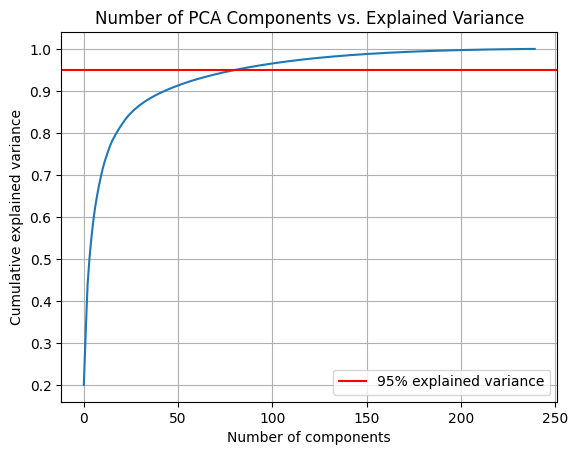

In [102]:
# plot a graph to figure out the optimal number of PCA components
pca = PCA().fit(X_train_tsf1_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color="red", label="95% explained variance")
plt.legend()
plt.grid(True)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Number of PCA Components vs. Explained Variance")

In [103]:
# identify the specific number of components
opt_n = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95)
print(f"Optimal number of PCA components: {opt_n}")

Optimal number of PCA components: 81


In [113]:
# apply PCA
pca = PCA(n_components=81)
X_train_pca = pca.fit_transform(X_train_tsf1_scaled)
X_test_pca = pca.transform(X_test_tsf1_scaled)

# # feed the data into an SVM
svm = SVC()
svm.fit(X_train_pca, y_train_tsf1)
predicted = svm.predict(X_test_pca)

accuracy = accuracy_score(y_test_tsf1, predicted)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test_tsf1, predicted))

Accuracy: 0.9833333333333333
              precision    recall  f1-score   support

           1       1.00      0.95      0.97        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

